# Rate Sequences with Extra Reactants

Sometimes we want to approximate rate sequences and include additional reactants the represent nuclei consumed by the sequence, but we don't want these to be used in the evaluation of the rate.  This capability is provided by the `not_in_ydot_term` argument to {py:obj}`Rate <pynucastro.rates.rate.Rate>`.

As a concrete example, consider the following sequence in the PP-II chain:

$${}^4{\rm He}({}^3{\rm He},\gamma){}^7{\rm Be}(e^-,\nu){}^7{\rm Li}(p,\alpha){}^4{\rm He}$$

We want this sequence to appear in the evolution equations for $dY(p)/dt$, $dY({}^3\mathrm{He})/dt$, and $dY({}^4\mathrm{He})/dt$, but we want to use just the first rate in the sequence to evaluate it, i.e., the term in the $\dot{Y}$ equations should be:

$$\rho \, Y({}^3\mathrm{He}) Y({}^4\mathrm{He}) \, \lambda_{{}^4\mathrm{He}({}^3\mathrm{He},\gamma){}^7\mathrm{Be}}$$

Let's start by creating this rate to represent the sequence.  We'll use {py:obj}`ModifiedRate <pynucastro.rates.modified_rate.ModifiedRate>`.

In [1]:
import pynucastro as pyna

In [2]:
rl = pyna.ReacLibLibrary()

Get the rate that will be used to evaluate the entire sequence:

In [3]:
rhe3he4 = rl.get_rate_by_name("he4(he3,g)be7")

When we create the `ModifiedRate`, we add protons to `new_reactants`, but we also add them to `not_in_ydot_term`.  Adding protons to `new_reactants` ensures that this rate appears in the evolution equation $dY(p)/dt$.  Adding protons to `not_in_ydot_term` ensures that $Y(p)$ is not used in constructing the rate term that goes into the evolution equations.

In [4]:
rnew = pyna.ModifiedRate(rhe3he4,
                         new_reactants=[pyna.Nucleus("he4"), pyna.Nucleus("he3"), pyna.Nucleus("p")],
                         new_products=[pyna.Nucleus("he4"), pyna.Nucleus("he4")],
                         not_in_ydot_term=[pyna.Nucleus("p")],
                         description="He4(He3,γ)Be7(e⁻,ν)Li7(p,α)He4")

We can see that the rate has the reactants we desired

In [5]:
rnew

He3 + He4 + p ⟶ He4 + He4 + e⁺ + 𝜈

and the $\dot{Y}$ term is the way we wanted:

In [6]:
rnew.ydot_string_py()

'rho*Y[jhe3]*Y[jhe4]*rate_eval.He3_He4_p_to_He4_He4_beta_pos_modified'

## An approximate PP network

Now we'll create a network that approximates PP-I, II, and III.  We start by getting the rates involved in PP-I:

In [7]:
rpp = rl.get_rate_by_name("p(p,)d")
rdp = rl.get_rate_by_name("d(p,)he3")
rhe3he3 = rl.get_rate_by_name("he3(he3,pp)he4")

Note that `rpp` is actually two rates

In [8]:
rpp

[p + p ⟶ H2 + e⁺ + 𝜈, p + p + e⁻ ⟶ H2 + 𝜈]

Now we create a network with the PP-I rates and our `ModifiedRate`.  Note that our approximate rate constructed above serves as an approximation to both PP-II and PP-III.  We would only need to treat them separately if we were tracking the neutrino energies.

In [9]:
net_approx = pyna.PythonNetwork(rates=[rpp[0], rpp[1], rdp, rhe3he3, rnew])

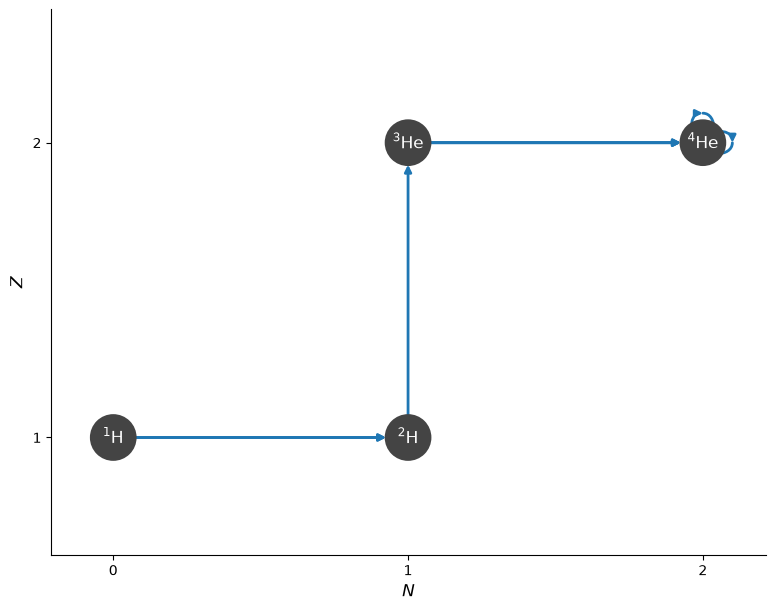

In [10]:
fig = net_approx.plot(always_show_alpha=True)

Notice that the evolution of protons includes our approximate rate:

In [11]:
fstr = net_approx.full_ydot_string(pyna.Nucleus("p"))
print(fstr)

dYdt[jp] = (
      + -2*5.00000000000000e-01*rho*Y[jp]**2*rate_eval.p_p_to_d_beta_pos_reaclib  +
      + -2*5.00000000000000e-01*rho**2*ye(Y)*Y[jp]**2*rate_eval.p_p_to_d_electron_capture_reaclib  +
      -rho*Y[jp]*Y[jd]*rate_eval.d_p_to_He3_reaclib  +
      + 2*5.00000000000000e-01*rho*Y[jhe3]**2*rate_eval.He3_He3_to_p_p_He4_reaclib  +
      -rho*Y[jhe3]*Y[jhe4]*rate_eval.He3_He4_p_to_He4_He4_beta_pos_modified
   )




Now we can integrate the network.

The PP-II rate dominates at temperatures  $\ge 2\times 10^7~\mathrm{K}$, so we'll use conditions slightly hotter than the Sun's core.

In [12]:
rho = 150
T = 2.2e7

In [13]:
comp_approx = pyna.Composition(net_approx.unique_nuclei, small=0.0)
comp_approx.X[pyna.Nucleus("p")] = 0.74
comp_approx.X[pyna.Nucleus("he3")] = 1.e-4
comp_approx.X[pyna.Nucleus("he4")] = 1.0 - comp_approx.X[pyna.Nucleus("p")] - comp_approx.X[pyna.Nucleus("he3")] 

In [14]:
tmax = 1.e20

In [15]:
sol_approx = net_approx.integrate_network(tmax, rho, T, comp_approx)

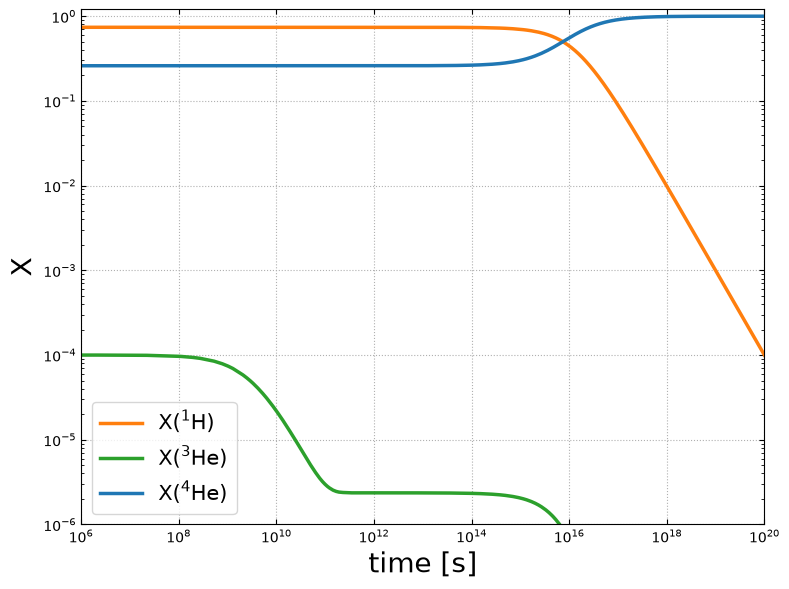

In [16]:
fig = sol_approx.plot_evolution(ymin=1.e-6, tmin=1.e6)

## PP-I only

Now let's look at the same conditions, but just with the PP-I rates.

In [17]:
net_ppI = pyna.PythonNetwork(rates=[rpp[0], rpp[1], rdp, rhe3he3])

We can use the same composition, since the nuclei are the same

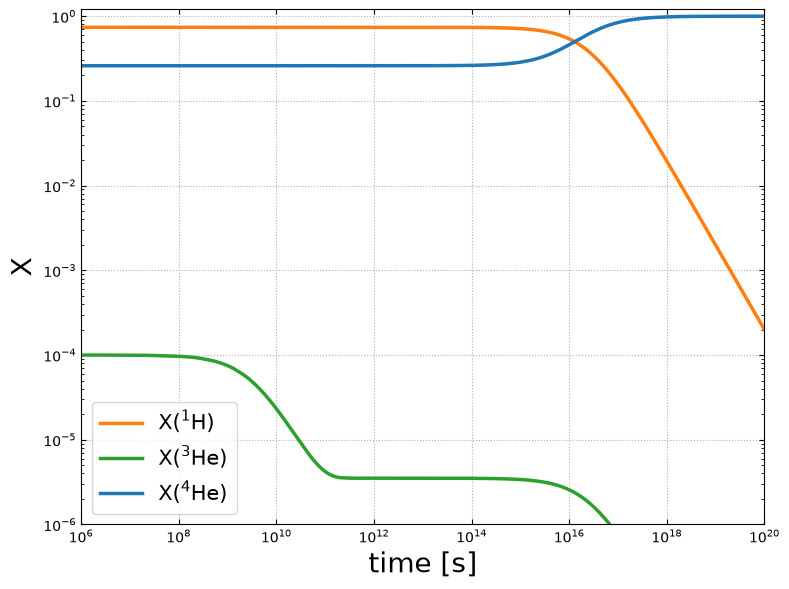

In [18]:
sol_ppI = net_ppI.integrate_network(tmax, rho, T, comp_approx)
fig = sol_ppI.plot_evolution(ymin=1.e-6, tmin=1.e6)

We see that the trends are the same, but the ${}^3\mathrm{He}$ is not depleted as much

## A full PP network

Now let's create a PP-{I,II,III} network with all the necessary rates--no approximations.  Note that ReacLib doesn't include the
${}^8\mathrm{Be} \rightarrow {}^4\mathrm{He} + {}^4\mathrm{He}$ rate separately, but instead has ${}^8\mathrm{B}$
decay directly (it is actually doing ${}^8\mathrm{B} \rightarrow {}^8\mathrm{Be} + e^+ + \nu_e$ followed immediately by the decay of ${}^8\mathrm{Be}$).

In [19]:
net = pyna.network_helper(["p", "d", "he3", "he4",
                           "li7", "be7", "b8"],
                          with_reverse=False)

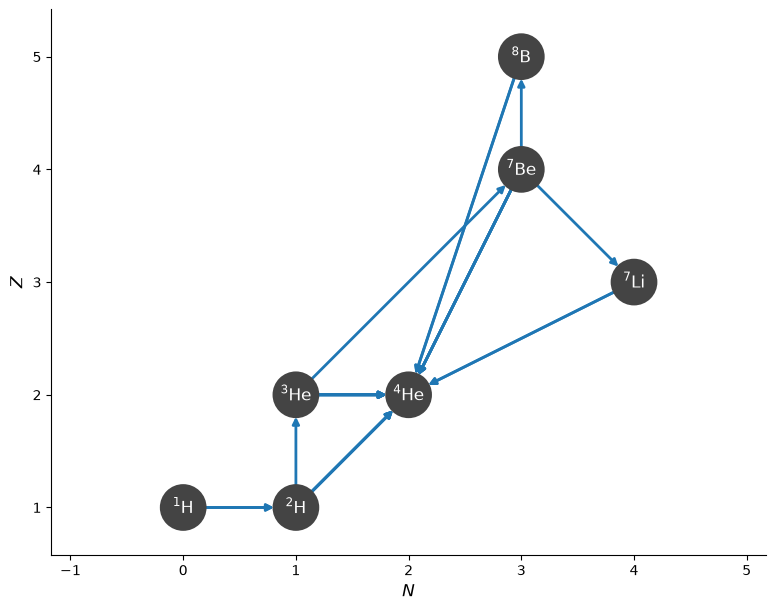

In [20]:
fig = net.plot(always_show_alpha=True)

Let's verify how the ${}^8\mathrm{B}$ decay works

In [21]:
print(net.full_ydot_string(pyna.Nucleus("b8")))

dYdt[jb8] = (
      -Y[jb8]*rate_eval.B8_to_He4_He4_beta_pos_reaclib  +
      +rho*Y[jp]*Y[jbe7]*rate_eval.Be7_p_to_B8_reaclib
   )




In [22]:
rb8 = net.get_rate_by_name("b8(,a)he4")
rb8

B8 ⟶ He4 + He4 + e⁺ + 𝜈

We see that ${}^8\mathrm{B}$ decays directly into two $\alpha$ + the positron and neutrino from the initial decay into ${}^8\mathrm{Be}$.

Now we can integrate this network

In [23]:
comp = pyna.Composition(net.unique_nuclei, small=0.0)
comp.X[pyna.Nucleus("p")] = 0.74
comp.X[pyna.Nucleus("he3")] = 1.e-4
comp.X[pyna.Nucleus("he4")] = 1.0 - comp.X[pyna.Nucleus("p")] - comp.X[pyna.Nucleus("he3")] 

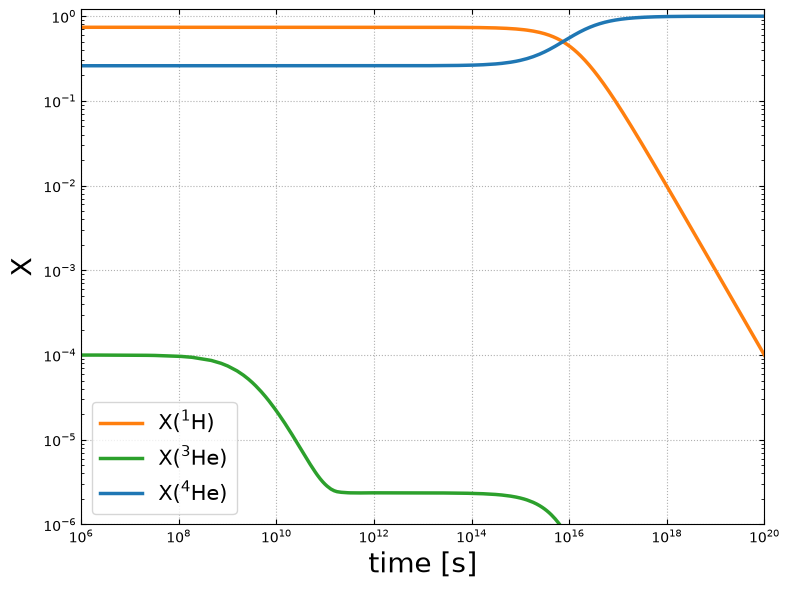

In [24]:
sol = net.integrate_network(tmax, rho, T, comp)
fig = sol.plot_evolution(ymin=1.e-6, tmin=1.e6)

As with the other networks, only 3 nuclei are abundant enough to show up in our evolution plot.

## Comparing our approximation

Now we can plot the evolution of all 3 networks on the same axes.

In [25]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

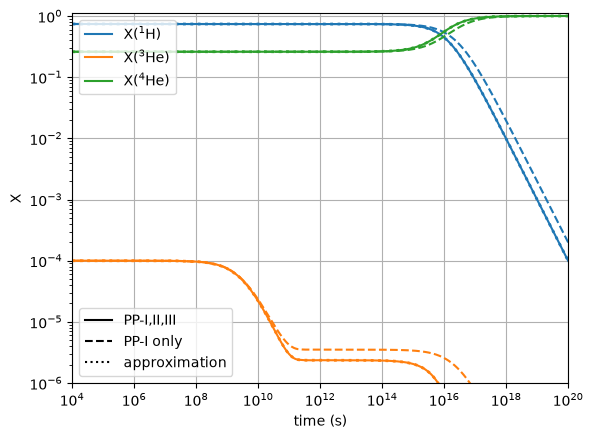

In [26]:
fig, ax = plt.subplots()

ic = 0
for i, nuc in enumerate(sol_approx.unique_nuclei):
    maxX = sol.X[i,:].max()
    if maxX < 1.e-6:
        continue
    ax.loglog(sol_approx.t, sol_approx.X[i, :],
              linestyle=":", lw=2, color=f"C{ic}")
    ax.loglog(sol_ppI.t, sol_ppI.X[i, :],
              linestyle="--", color=f"C{ic}")
    idx = sol.unique_nuclei.index(nuc)
    ax.loglog(sol.t, sol.X[idx, :],
              label=rf"X$({nuc.pretty})$", 
              linestyle="-", color=f"C{ic}")
    ic += 1
ax.set_xlim(1.e4, 1.e20)
ax.set_ylim(1.e-6, 1.1)

leg1 = ax.legend(loc="upper left")
ax.add_artist(leg1)

style_handles = [
    Line2D([0], [0], color="black", linestyle="-",  label="PP-I,II,III"),
    Line2D([0], [0], color="black", linestyle="--", label="PP-I only"),
    Line2D([0], [0], color="black", linestyle=":",  label="approximation"),
]

ax.legend(handles=style_handles)

ax.set_xlabel("time (s)")
ax.set_ylabel("X")

ax.grid()

We see that our approximation captures the behavior of the full PP network very well, while the PP-I only network takes longer to consume the H.